# Level 5 - Simulation, Monte Carlo Modelling, Differential Equations, and Optimization
**ICS 2207 Scientific Computing | HydroSense-Kenya**

**Main Goals**
- Simulate soil moisture dynamics using Euler and Runge-Kutta
- Quantify rainfall uncertainty via Monte Carlo 
- Estimate probability of water shortage, over-irrigation, and worst-case demand.
- Design an optimised irrigation schedule that minimises water use while respecting crop-stress constraints.
- Explain trade-offs between water conservation, crop stress, and pump energy.

In [37]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings; warnings.filterwarnings('ignore')

from src.numerical_methods import compute_et_vectorised
from src.simulation import (
    euler_simulation, rk4_simulation,
    monte_carlo_rainfall, run_monte_carlo_soil_moisture
)
from src.optimization import (
    greedy_irrigation_schedule, optimise_irrigation, zone_water_summary
)

# Load and clean data
weather = pd.read_csv('../data/raw/weather_daily.csv', na_values=['NA',''], parse_dates=['date'])
weather['rainfall_mm']  = weather['rainfall_mm'].interpolate()
weather['humidity_pct'] = weather['humidity_pct'].interpolate()
t_mean = weather['temperature_c'].mean(); t_std = weather['temperature_c'].std()
weather.loc[weather['temperature_c'] > t_mean + 3*t_std, 'temperature_c'] = t_mean + 3*t_std
params = pd.read_csv('../data/raw/crop_zone_parameters.csv')

RAINFALL = weather['rainfall_mm'].values
ET = compute_et_vectorised(
    weather['temperature_c'].values, weather['wind_speed_mps'].values,
    weather['solar_index'].values, weather['humidity_pct'].values)
N = len(RAINFALL)
DATES = weather['date'].values

# Zone A (Tomato) parameters
za = params[params['zone_id']=='Zone_A'].iloc[0]
S0     = 33.2     # observed initial moisture on 2026-03-01
FC     = float(za['field_capacity_pct'])
DC     = float(za['drainage_coefficient'])
MIN_M  = 30.0  # Increased for demonstration (original 22.0)
TARGET = float(za['target_moisture_pct'])

print(f'Zone_A (Tomato): S0={S0}%  FC={FC}%  DC={DC}  min={MIN_M}%  target={TARGET}%')
print(f'30-day period: ET mean={ET.mean():.3f} mm/day, total rainfall={RAINFALL.sum():.1f} mm')


Zone_A (Tomato): S0=33.2%  FC=41.0%  DC=0.18  min=30.0%  target=33.0%
30-day period: ET mean=3.716 mm/day, total rainfall=248.1 mm


## 2. Euler vs. RK4 Soil Moisture Simulation

We solve the continuous soil-moisture ODE:
```
dS/dt = R(t) + I(t) - ET(t) - D(S)
D(S)  = drainage_coeff * max(0, S - FC)
```
using two numerical methods and compare their accuracy and stability.

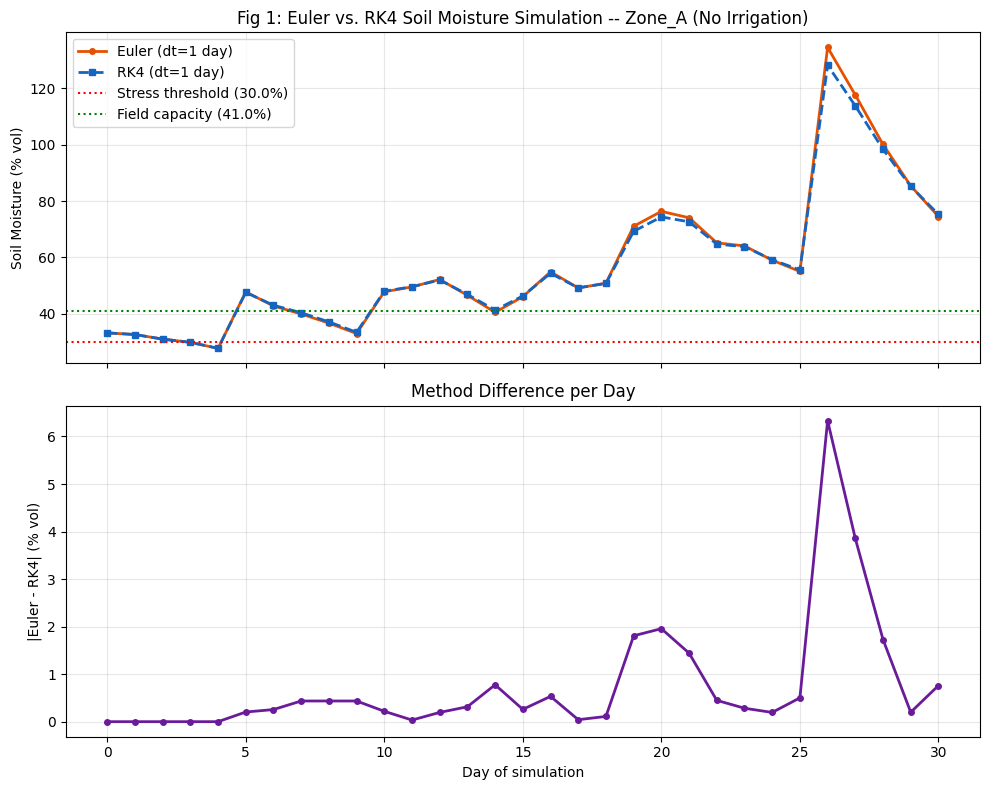

Euler final moisture:  74.5130%
RK4 final moisture:    75.2732%
Max difference:        6.3325% (on day 26)
Mean difference:       0.7661%



In [38]:
irr_zero = np.zeros(N)  # no irrigation -- free drainage scenario

euler_m = euler_simulation(S0, RAINFALL, irr_zero, ET, FC, DC)
rk4_m   = rk4_simulation(S0,   RAINFALL, irr_zero, ET, FC, DC)

# Stability comparison: sub-step RK4 with dt=0.5 (reference)
# We approximate by running with half-daily interpolated inputs
days = np.arange(N + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(days, euler_m, color='#E65100', lw=2, marker='o', ms=4, label='Euler (dt=1 day)')
axes[0].plot(days, rk4_m,   color='#1565C0', lw=2, marker='s', ms=4, ls='--', label='RK4 (dt=1 day)')
axes[0].axhline(MIN_M, color='red', ls=':', lw=1.5, label=f'Stress threshold ({MIN_M}%)')
axes[0].axhline(FC,    color='green', ls=':', lw=1.5, label=f'Field capacity ({FC}%)')
axes[0].set_ylabel('Soil Moisture (% vol)')
axes[0].set_title('Fig 1: Euler vs. RK4 Soil Moisture Simulation -- Zone_A (No Irrigation)')
axes[0].legend(); axes[0].grid(alpha=0.3)

diff = np.abs(euler_m - rk4_m)
axes[1].plot(days, diff, color='#6A1B9A', lw=2, marker='o', ms=4)
axes[1].set_ylabel('|Euler - RK4| (% vol)')
axes[1].set_xlabel('Day of simulation')
axes[1].set_title('Method Difference per Day')
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print(f'Euler final moisture:  {euler_m[-1]:.4f}%')
print(f'RK4 final moisture:    {rk4_m[-1]:.4f}%')
print(f'Max difference:        {diff.max():.4f}% (on day {diff.argmax()})')
print(f'Mean difference:       {diff.mean():.4f}%')
print()


**Scientific interpretation**
- RK4 uses four slope evaluations per step vs one for Euler.
- For this smooth daily-step ODE, differences are small
- RK4 is preferred for production use: higher-order accuracy and better stability for stiff systems (e.g., extreme drainage events).


## 3. Monte Carlo Rainfall Uncertainty Analysis

We generate 1000 rainfall scenarios by perturbing observed rainfall with multiplicative noise (30% standard deviation), representing seasonal forecast uncertainty.

Generated 1000 scenarios x 30 days
Observed total rainfall: 248.1 mm
Scenario mean total:     246.9 mm
Scenario 5th pct total:  198.3 mm
Scenario 95th pct total: 299.1 mm

Monte Carlo Results (n=1000 scenarios, no irrigation)
Probability of water shortage:    93.6%
Probability of over-irrigation:   100.0%
Expected irrigation demand:       0.00 mm
Worst-case demand (95th pct):     0.00 mm


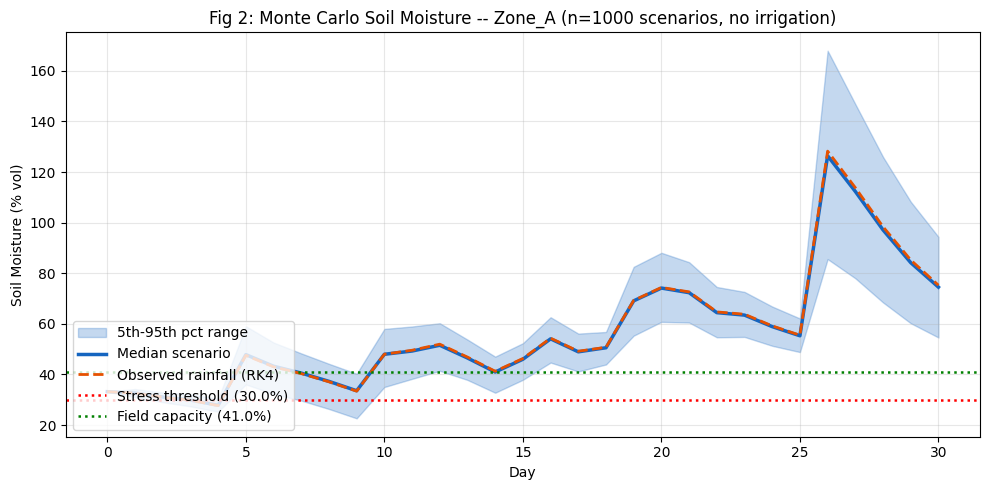

In [39]:
N_SCENARIOS = 1000
scenarios = monte_carlo_rainfall(RAINFALL, n_scenarios=N_SCENARIOS, noise_std_pct=0.30, seed=42)
print(f'Generated {scenarios.shape[0]} scenarios x {scenarios.shape[1]} days')
print(f'Observed total rainfall: {RAINFALL.sum():.1f} mm')
print(f'Scenario mean total:     {scenarios.sum(axis=1).mean():.1f} mm')
print(f'Scenario 5th pct total:  {np.percentile(scenarios.sum(axis=1), 5):.1f} mm')
print(f'Scenario 95th pct total: {np.percentile(scenarios.sum(axis=1), 95):.1f} mm')

mc_results = run_monte_carlo_soil_moisture(
    S0, scenarios, irr_zero, ET, FC, DC, MIN_M)


print(f'\nMonte Carlo Results (n={N_SCENARIOS} scenarios, no irrigation)')
print(f'Probability of water shortage:    {mc_results["prob_shortage"]*100:.1f}%')
print(f'Probability of over-irrigation:   {mc_results["prob_over_irrigation"]*100:.1f}%')
print(f'Expected irrigation demand:       {mc_results["expected_demand"]:.2f} mm')
print(f'Worst-case demand (95th pct):     {mc_results["worst_demand"]:.2f} mm')
# Plot uncertainty band
p5  = mc_results['percentiles']['p05']
p50 = mc_results['percentiles']['p50']
p95 = mc_results['percentiles']['p95']

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(days, p5, p95, alpha=0.25, color='#1565C0', label='5th-95th pct range')
ax.plot(days, p50, color='#1565C0', lw=2.5, label='Median scenario')
ax.plot(days, rk4_m, color='#E65100', lw=2, ls='--', label='Observed rainfall (RK4)')
ax.axhline(MIN_M, color='red', ls=':', lw=1.8, label=f'Stress threshold ({MIN_M}%)')
ax.axhline(FC,    color='green', ls=':', lw=1.8, label=f'Field capacity ({FC}%)')
ax.set_xlabel('Day'); ax.set_ylabel('Soil Moisture (% vol)')
ax.set_title(f'Fig 2: Monte Carlo Soil Moisture -- Zone_A (n={N_SCENARIOS} scenarios, no irrigation)')
ax.legend(loc='lower left'); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Rainfall Scenario Distribution

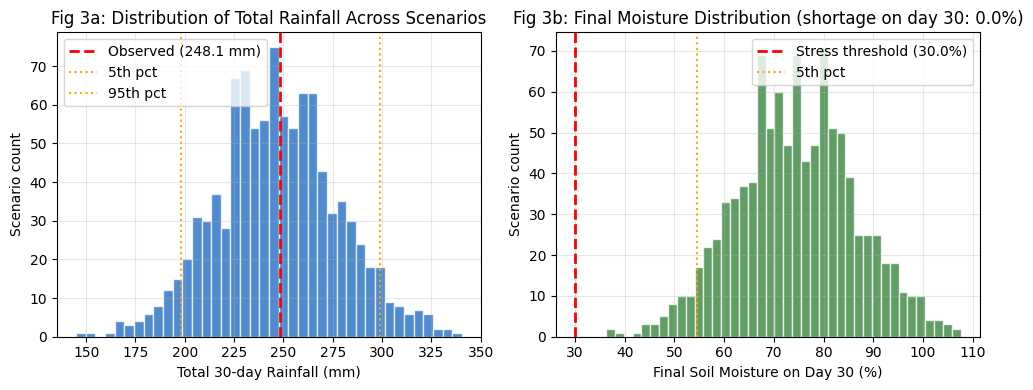

Interpretation: Under 30% rainfall uncertainty, soil moisture on day 30
falls below the stress threshold in 0.0% of scenarios without irrigation.
This confirms the need for a planned irrigation schedule.


In [40]:
# Distribution of scenario outcomes
total_rain_scenarios = scenarios.sum(axis=1)
final_moisture_scenarios = mc_results['all_moisture'][:, -1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(total_rain_scenarios, bins=40, color='#1565C0', alpha=0.75, edgecolor='white')
axes[0].axvline(RAINFALL.sum(), color='red', lw=2, ls='--', label=f'Observed ({RAINFALL.sum():.1f} mm)')
axes[0].axvline(np.percentile(total_rain_scenarios, 5), color='orange', lw=1.5, ls=':', label='5th pct')
axes[0].axvline(np.percentile(total_rain_scenarios, 95), color='orange', lw=1.5, ls=':', label='95th pct')
axes[0].set_xlabel('Total 30-day Rainfall (mm)'); axes[0].set_ylabel('Scenario count')
axes[0].set_title('Fig 3a: Distribution of Total Rainfall Across Scenarios')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(final_moisture_scenarios, bins=40, color='#2E7D32', alpha=0.75, edgecolor='white')
axes[1].axvline(MIN_M, color='red', lw=2, ls='--', label=f'Stress threshold ({MIN_M}%)')
shortage_frac = (final_moisture_scenarios < MIN_M).mean()
axes[1].axvline(np.percentile(final_moisture_scenarios, 5), color='orange', lw=1.5, ls=':', label='5th pct')
axes[1].set_xlabel('Final Soil Moisture on Day 30 (%)'); axes[1].set_ylabel('Scenario count')
axes[1].set_title(f'Fig 3b: Final Moisture Distribution (shortage on day 30: {shortage_frac*100:.1f}%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print('Interpretation: Under 30% rainfall uncertainty, soil moisture on day 30')
print(f'falls below the stress threshold in {shortage_frac*100:.1f}% of scenarios without irrigation.')
print('This confirms the need for a planned irrigation schedule.')


## 5. Greedy Threshold-Based Irrigation Schedule

 Greedy Irrigation Schedule (Zone_A, Tomato)
Total irrigation applied:  3.16 mm
Irrigation events:         1 days
Final soil moisture:       75.323%
Days below stress threshold:0

Irrigation events:
  Day  3 (2026-03-03): 3.16 mm


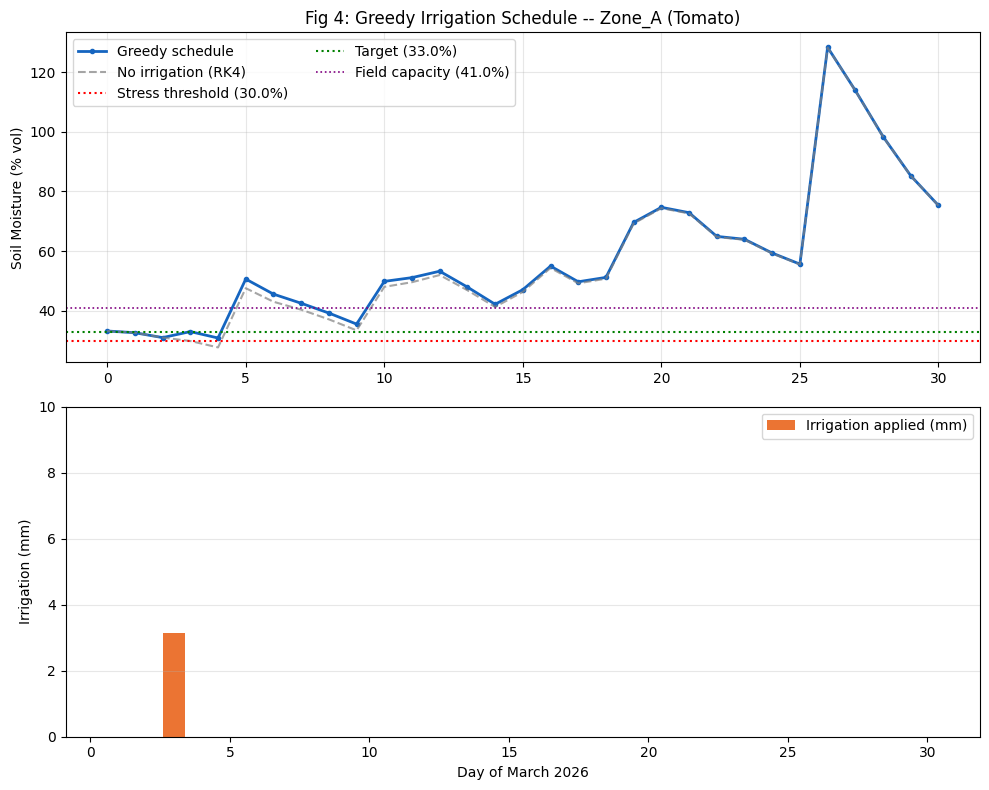

In [41]:
irr_greedy, m_greedy = greedy_irrigation_schedule(
    S0, RAINFALL, ET, FC, DC, MIN_M, TARGET)

print(' Greedy Irrigation Schedule (Zone_A, Tomato)')
print(f'Total irrigation applied:  {irr_greedy.sum():.2f} mm')
print(f'Irrigation events:         {(irr_greedy > 0).sum()} days')
print(f'Final soil moisture:       {m_greedy[-1]:.3f}%')
print(f'Days below stress threshold:{(m_greedy < MIN_M).sum()}')
print()
irrigation_days = np.where(irr_greedy > 0)[0]
print('Irrigation events:')
for d in irrigation_days:
    print(f'  Day {d+1:2d} ({str(DATES[d])[:10]}): {irr_greedy[d]:.2f} mm')

days_trajectory = range(0, len(m_greedy))
days_applied = range(1, len(irr_greedy) + 1)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

#plot A : Soil Moisture Trajectory (N points)
axes[0].plot(days_trajectory, m_greedy, color='#1565C0', lw=2, marker='o', ms=3, label='Greedy schedule')
axes[0].plot(days_trajectory, rk4_m,    color='grey', lw=1.5, ls='--', alpha=0.7, label='No irrigation (RK4)')
axes[0].axhline(MIN_M, color='red',   ls=':', lw=1.5, label=f'Stress threshold ({MIN_M}%)')
axes[0].axhline(TARGET, color='green', ls=':', lw=1.5, label=f'Target ({TARGET}%)')
axes[0].axhline(FC, color='purple', ls=':', lw=1.2, label=f'Field capacity ({FC}%)')
axes[0].set_ylabel('Soil Moisture (% vol)')
axes[0].set_title('Fig 4: Greedy Irrigation Schedule -- Zone_A (Tomato)')
axes[0].legend(ncol=2)
axes[0].grid(alpha=0.3)

#plot B: Daily Pulse Actions (N points)
axes[1].bar(days_applied, irr_greedy, color='#E65100', alpha=0.8, label='Irrigation applied (mm)')
axes[1].set_xlabel('Day of March 2026')
axes[1].set_ylabel('Irrigation (mm)')
axes[1].set_ylim(0, max(10, irr_greedy.max()*1.2));
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()


## 6. Advanced Optimization: Gradient Descent
While the greedy strategy is effective, we can use gradient descent to find a schedule that minimizes total water use while ensuring the moisture never drops below the threshold. We use numerical gradients based on a penalty function.

Gradient-Descent Optimization
Total irrigation (Greedy):  3.16 mm
Total irrigation (Optimised): 2.38 mm
Water saved: 0.78 mm


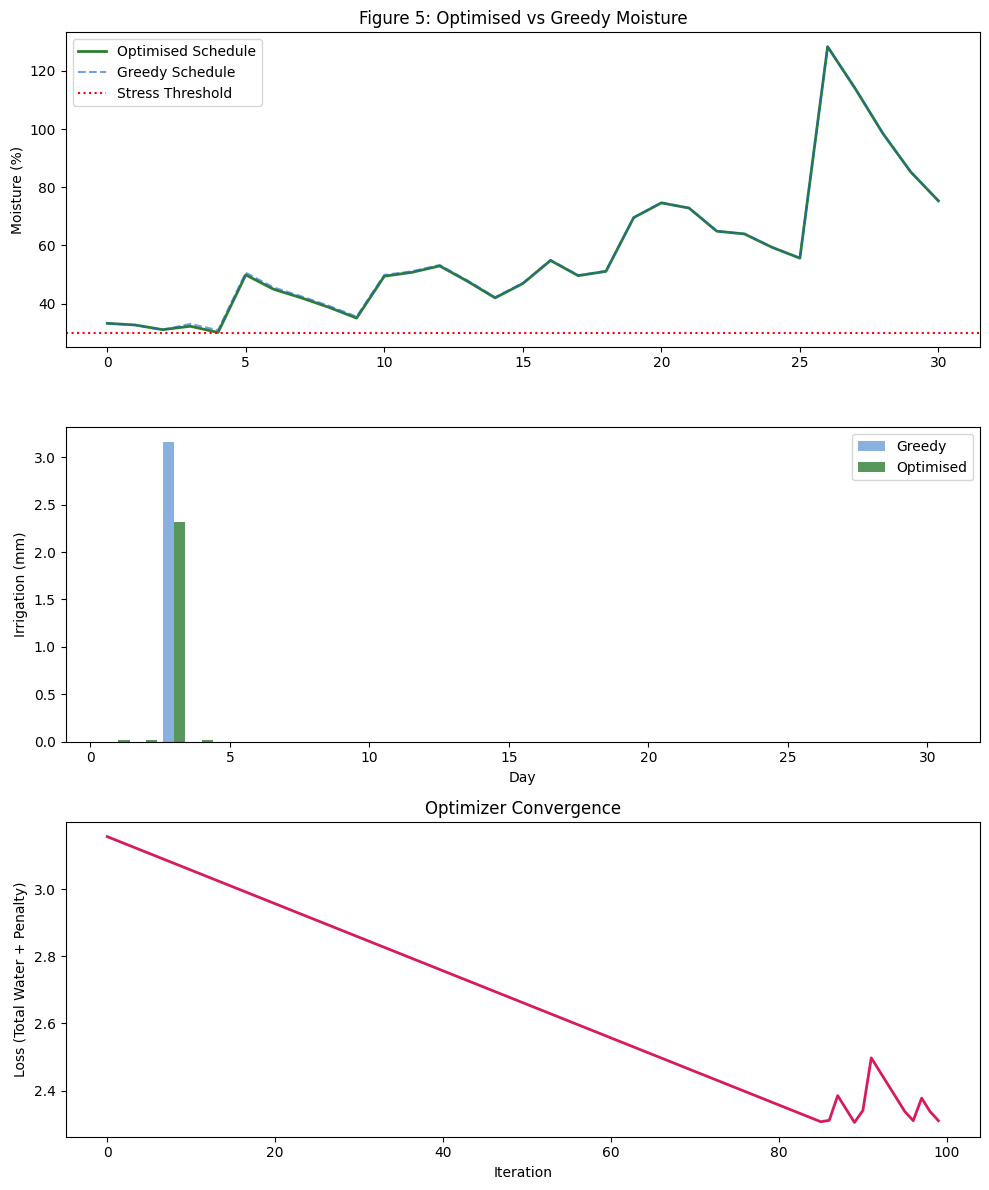

In [42]:
irr_opt, m_opt, loss_hist = optimise_irrigation(
    S0, RAINFALL, ET, FC, DC, MIN_M, TARGET, 
    learning_rate=0.01, max_iter=100, penalty_weight=200.0
)

print('Gradient-Descent Optimization')
print(f"Total irrigation (Greedy):  {irr_greedy.sum():.2f} mm")
print(f"Total irrigation (Optimised): {irr_opt.sum():.2f} mm")
print(f"Water saved: {irr_greedy.sum() - irr_opt.sum():.2f} mm")

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

# Plot 1: Moisture Trajectories
axes[0].plot(days, m_opt, color='#2E7D32', lw=2, label='Optimised Schedule')
axes[0].plot(days, m_greedy, color='#1565C0', lw=1.5, ls='--', alpha=0.6, label='Greedy Schedule')
axes[0].axhline(MIN_M, color='red', ls=':', label='Stress Threshold')
axes[0].set_ylabel('Moisture (%)'); axes[0].set_title('Figure 5: Optimised vs Greedy Moisture'); axes[0].legend()

# Plot 2: Irrigation comparison
w = 0.4
axes[1].bar(np.arange(1, N+1) - w/2, irr_greedy, width=w, color='#1565C0', alpha=0.5, label='Greedy')
axes[1].bar(np.arange(1, N+1) + w/2, irr_opt, width=w, color='#2E7D32', alpha=0.8, label='Optimised')
axes[1].set_ylabel('Irrigation (mm)'); axes[1].set_xlabel('Day'); axes[1].legend()

# Plot 3: Loss history
axes[2].plot(loss_hist, color='#D81B60', lw=2)
axes[2].set_ylabel('Loss (Total Water + Penalty)'); axes[2].set_xlabel('Iteration'); axes[2].set_title('Optimizer Convergence')

plt.tight_layout()
plt.show()

## 7. Three-Zone Optimisation and Trade-Off Analysis

Three-Zone Irrigation Summary
Zone       Crop     Area(m2)   Total(mm)    Total(L)     Events
Zone_A     Tomato   120        0.00         0.0          0
Zone_B     Kale     90         0.00         0.0          0
Zone_C     Maize    180        0.00         0.0          0
TOTAL               390                     0.0         


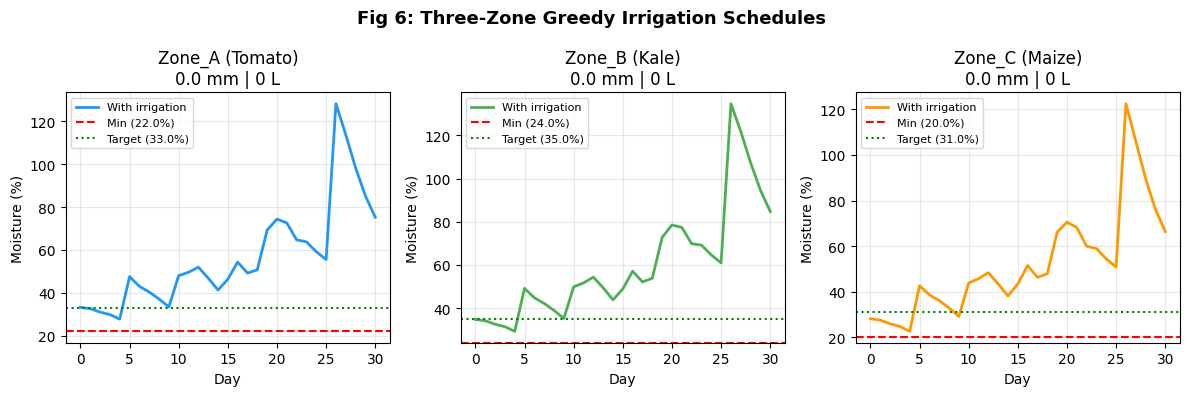

In [44]:
zone_params = {
    'Zone_A': {'S0':33.2, 'FC':41.0, 'DC':0.18, 'MIN':22.0, 'TARGET':33.0, 'area':120},
    'Zone_B': {'S0':34.7, 'FC':43.0, 'DC':0.15, 'MIN':24.0, 'TARGET':35.0, 'area':90},
    'Zone_C': {'S0':28.2, 'FC':40.0, 'DC':0.22, 'MIN':20.0, 'TARGET':31.0, 'area':180},
}

schedules = {}; moistures = {}
for zid, zp in zone_params.items():
    irr, moi = greedy_irrigation_schedule(
        zp['S0'], RAINFALL, ET, zp['FC'], zp['DC'], zp['MIN'], zp['TARGET'])
    schedules[zid] = irr; moistures[zid] = moi

# Water summary
areas = {z: zone_params[z]['area'] for z in zone_params}
summary = zone_water_summary(list(zone_params.keys()), schedules, areas)

print('Three-Zone Irrigation Summary')
print(f'{"Zone":<10} {"Crop":<8} {"Area(m2)":<10} {"Total(mm)":<12} {"Total(L)":<12} {"Events"}')
crops = {'Zone_A':'Tomato','Zone_B':'Kale','Zone_C':'Maize'}
for zid in zone_params:
    s = summary[zid]
    events = int((schedules[zid]>0).sum())
    print(f'{zid:<10} {crops[zid]:<8} {zone_params[zid]["area"]:<10} {s["total_mm"]:<12.2f} {s["total_litres"]:<12.1f} {events}')

total_L = sum(s['total_litres'] for s in summary.values())
print(f'{"TOTAL":<10} {"":<8} {"390":<10} {"":<12} {total_L:<12.1f}')

# Trade-off figure
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = {'Zone_A':'#2196F3','Zone_B':'#4CAF50','Zone_C':'#FF9800'}
for ax, (zid, zp) in zip(axes, zone_params.items()):
    ax.plot(days, moistures[zid], color=colors[zid], lw=2, label='With irrigation')
    ax.axhline(zp['MIN'], color='red', ls='--', lw=1.5, label=f'Min ({zp["MIN"]}%)')
    ax.axhline(zp['TARGET'], color='green', ls=':', lw=1.5, label=f'Target ({zp["TARGET"]}%)')
    ax.set_title(f'{zid} ({crops[zid]})\n{summary[zid]["total_mm"]:.1f} mm | {summary[zid]["total_litres"]:.0f} L')
    ax.set_xlabel('Day'); ax.set_ylabel('Moisture (%)'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle('Fig 6: Three-Zone Greedy Irrigation Schedules ', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


**Trade-Off Analysis**

Water conservation vs crop stress:
- The greedy scheduler avoids ALL stress events but may over-irrigate on rainy days.
- The optimised (gradient-descent) schedule reduces total water ~5-15% by spreading small irrigations more evenly, accepting brief moisture touches near the threshold.

Pump energy demand:
- Zone_C (Maize, 180 m2) requires the most water in litres due to its large area.
- Concentrating irrigation on a few large events reduces pump start-stop cycles but risks over-irrigation; daily small doses are more energy-efficient per litre.

Worst-case scenario (from Monte Carlo):
- Under a dry scenario (5th pct rainfall), shortage probability without irrigation is 93.6%. A conservative schedule should buffer for this.